# Financial Analyst Chatbot

The next iteration of the financial market assistant. Same underlying
loop-based LangGraph architecture as before, extended with the five next
steps identified in that notebook, plus a market sentiment tool.

**New in this version:**

1. **Fundamentals, not just price.** A new tool pulls P/E ratio, EPS, market
   cap, dividend yield, and profit margin, so the model can answer "is this
   stock expensive" questions, not only "what is the price" questions.
2. **Multi-turn memory.** A checkpointer means a follow-up like "now do the
   same for Microsoft" is understood in the context of the previous message,
   instead of the assistant needing the full question repeated.
3. **A portfolio tool.** Give it a list of tickers and weights, and it
   computes combined weighted performance, not just one stock at a time.
4. **A companion Streamlit app.** The notebook's chat loop and tools are
   reused, unchanged, in a small standalone app with the chart displayed
   next to the conversation rather than underneath it.
5. **A disclaimer guardrail, enforced in the graph, not just the prompt.**
   A dedicated node inspects the model's final answer for buy or sell
   framing and attaches a disclaimer automatically, rather than trusting the
   system prompt alone to remember to add one.
6. **Market sentiment.** A tool that pulls recent news for a stock or index
   and has a separate, smaller LLM call classify it as positive, negative,
   neutral, or mixed, with the headlines that led to that call.

Run the cells top to bottom. You will need `GROQ_API_KEY` and
`TAVILY_API_KEY` in a `.env` file.

## Configuration

This includes every fix worked out while building the first version: SSL
handling for Groq/Wikipedia/HuggingFace-style calls, a separate certificate
fix specifically for `yfinance` (which uses its own HTTP library internally
and does not pick up the first fix), and the Wikipedia User-Agent
requirement.

In [66]:
import truststore
truststore.inject_into_ssl()

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

import wikipedia
import requests as _requests

if not getattr(_requests.get, "_is_patched", False):
    _original_get = _requests.get

    def _patched_get(*args, **kwargs):
        headers = kwargs.get("headers", {})
        headers["User-Agent"] = "FinancialAssistant/1.0 (educational project)"
        kwargs["headers"] = headers
        return _original_get(*args, **kwargs)

    _patched_get._is_patched = True
    _requests.get = _patched_get

print("Groq key loaded:", bool(os.environ.get("GROQ_API_KEY")))
print("Tavily key loaded:", bool(os.environ.get("TAVILY_API_KEY")))

Groq key loaded: True
Tavily key loaded: True


In [67]:
# yfinance uses curl_cffi internally, which does not use Python's normal SSL
# stack, so truststore above does not reach it. This patches it separately.
import certifi

os.environ["CURL_CA_BUNDLE"] = certifi.where()
os.environ["SSL_CERT_FILE"] = certifi.where()

import curl_cffi.requests as ccr

if not getattr(ccr.Session.__init__, "_is_patched", False):
    _original_session_init = ccr.Session.__init__

    def _patched_session_init(self, *args, **kwargs):
        kwargs.setdefault("verify", False)
        return _original_session_init(self, *args, **kwargs)

    _patched_session_init._is_patched = True
    ccr.Session.__init__ = _patched_session_init

import yfinance as yf
print("yfinance ready.")

yfinance ready.


## General-purpose tools

Carried over unchanged from the first version.

In [68]:
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun
import arxiv as arxiv_pkg


def _fixed_arxiv_run(self, query: str) -> str:
    try:
        results = arxiv_pkg.Client().results(
            self.arxiv_search(query[: self.ARXIV_MAX_QUERY_LENGTH], max_results=self.top_k_results)
        )
        docs = [
            f"Published: {r.updated.date()}\nTitle: {r.title}\nAuthors: {', '.join(a.name for a in r.authors)}\nSummary: {r.summary}"
            for r in results
        ]
        return "\n\n".join(docs)[: self.doc_content_chars_max] if docs else "No good Arxiv Result was found"
    except Exception as e:
        return f"Arxiv exception: {e}"


ArxivAPIWrapper.run = _fixed_arxiv_run

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults(max_results=4)

print("General-purpose tools ready.")

General-purpose tools ready.


## Core financial tools

The stock quote, market overview, chart, and currency tools, unchanged from
the first version.

In [69]:
from langchain_core.tools import tool


@tool
def get_stock_quote(ticker: str) -> str:
    '''Get the current price, daily change, volume, and market cap for a stock
    ticker symbol, for example AAPL, MSFT, or TSLA. Use this whenever the user
    asks for a specific stock's current price, quote, or how a stock is doing
    today.'''
    try:
        stock = yf.Ticker(ticker.upper())
        info = stock.fast_info

        price = info.last_price
        prev_close = info.previous_close
        change = price - prev_close
        pct_change = (change / prev_close) * 100 if prev_close else 0.0

        return (
            f"{ticker.upper()} quote:\n"
            f"Price: ${price:,.2f}\n"
            f"Change: {change:+.2f} ({pct_change:+.2f}%)\n"
            f"Day range: ${info.day_low:,.2f} - ${info.day_high:,.2f}\n"
            f"52 week range: ${info.year_low:,.2f} - ${info.year_high:,.2f}\n"
            f"Volume: {info.last_volume:,.0f}"
        )
    except Exception as e:
        return f"Could not retrieve a quote for '{ticker}': {e}"


@tool
def get_market_overview() -> str:
    '''Get the current level and daily percentage change for major stock market
    indices: S&P 500, Nasdaq, Dow Jones, and FTSE 100. Use this when the user
    asks a general question about how the market or markets are doing today,
    rather than about one specific stock.'''
    indices = {"S&P 500": "^GSPC", "Nasdaq": "^IXIC", "Dow Jones": "^DJI", "FTSE 100": "^FTSE"}
    lines = []
    for name, symbol in indices.items():
        try:
            info = yf.Ticker(symbol).fast_info
            change_pct = ((info.last_price - info.previous_close) / info.previous_close) * 100
            lines.append(f"{name}: {info.last_price:,.2f} ({change_pct:+.2f}%)")
        except Exception as e:
            lines.append(f"{name}: unavailable ({e})")
    return "Market overview:\n" + "\n".join(lines)

In [70]:
import matplotlib.pyplot as plt

os.makedirs("charts", exist_ok=True)


@tool
def plot_stock_chart(ticker: str, period: str = "3mo") -> str:
    '''Generate a price history chart for a stock ticker over a given period and
    save it to disk. Valid periods include 1mo, 3mo, 6mo, 1y, and 5y. Use this
    when the user asks to see a chart, graph, or price trend for a stock, not
    just its current price.'''
    try:
        history = yf.Ticker(ticker.upper()).history(period=period)
        if history.empty:
            return f"No price history found for '{ticker}'."

        start_price = history["Close"].iloc[0]
        end_price = history["Close"].iloc[-1]
        pct_change = ((end_price - start_price) / start_price) * 100
        high = history["Close"].max()
        low = history["Close"].min()

        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(history.index, history["Close"], linewidth=1.8)
        ax.set_title(f"{ticker.upper()} price, last {period}")
        ax.set_ylabel("Close price (USD)")
        ax.grid(alpha=0.25)
        fig.tight_layout()

        path = f"charts/{ticker.upper()}_{period}.png"
        fig.savefig(path, dpi=130)
        plt.close(fig)

        return (
            f"Chart saved to {path}. Over the last {period}, {ticker.upper()} moved from "
            f"${start_price:,.2f} to ${end_price:,.2f} ({pct_change:+.2f}%), "
            f"with a high of ${high:,.2f} and a low of ${low:,.2f}."
        )
    except Exception as e:
        return f"Could not generate a chart for '{ticker}': {e}"


@tool
def convert_currency(amount: float, from_currency: str, to_currency: str) -> str:
    '''Convert an amount of money from one currency to another using current
    exchange rates. Currencies should be given as three letter codes, for
    example USD, EUR, GBP. Use this when the user asks about currency
    conversion or exchange rates.'''
    try:
        url = "https://api.frankfurter.app/latest"
        params = {"amount": amount, "from": from_currency.upper(), "to": to_currency.upper()}
        response = _requests.get(url, params=params, timeout=10)
        data = response.json()
        converted = data["rates"][to_currency.upper()]
        rate = converted / amount
        return (
            f"{amount:,.2f} {from_currency.upper()} = {converted:,.2f} {to_currency.upper()} "
            f"(rate: 1 {from_currency.upper()} = {rate:.4f} {to_currency.upper()})"
        )
    except Exception as e:
        return f"Could not convert {from_currency} to {to_currency}: {e}"


print("Core financial tools ready.")

Core financial tools ready.


## New: company fundamentals

Price alone does not answer "is this stock expensive" or "does it pay a
dividend." This tool pulls the underlying business metrics instead of the
trading data.

In [71]:
@tool
def get_company_fundamentals(ticker: str) -> str:
    '''Get key financial ratios and fundamentals for a company: P/E ratio, EPS,
    market cap, dividend yield, and profit margin. Use this when the user asks
    whether a stock is expensive or cheap, about its earnings, dividends, or
    general financial health, as opposed to its current trading price.'''
    try:
        info = yf.Ticker(ticker.upper()).info

        def fmt_pct(key):
            value = info.get(key)
            return f"{value * 100:.2f}%" if isinstance(value, (int, float)) else "N/A"

        def fmt_num(key, prefix="", suffix=""):
            value = info.get(key)
            return f"{prefix}{value:,.2f}{suffix}" if isinstance(value, (int, float)) else "N/A"

        market_cap = info.get("marketCap")
        market_cap_str = f"${market_cap / 1e9:,.1f}B" if isinstance(market_cap, (int, float)) else "N/A"

        return (
            f"{ticker.upper()} fundamentals:\n"
            f"Company: {info.get('longName', ticker.upper())}\n"
            f"Sector: {info.get('sector', 'N/A')}\n"
            f"Market cap: {market_cap_str}\n"
            f"Trailing P/E: {fmt_num('trailingPE')}\n"
            f"Forward P/E: {fmt_num('forwardPE')}\n"
            f"EPS (trailing): {fmt_num('trailingEps', prefix='$')}\n"
            f"Dividend yield: {fmt_pct('dividendYield')}\n"
            f"Profit margin: {fmt_pct('profitMargins')}\n"
            f"Revenue growth (YoY): {fmt_pct('revenueGrowth')}"
        )
    except Exception as e:
        return f"Could not retrieve fundamentals for '{ticker}': {e}"


get_company_fundamentals.invoke({"ticker": "AAPL"})

'AAPL fundamentals:\nCompany: Apple Inc.\nSector: Technology\nMarket cap: $4,529.2B\nTrailing P/E: 35.59\nForward P/E: 32.54\nEPS (trailing): $8.72\nDividend yield: 35.00%\nProfit margin: 27.62%\nRevenue growth (YoY): 16.40%'

## New: portfolio performance

Takes a list of tickers and their weights and reports both the combined
weighted return and a per-holding breakdown, rather than requiring the user
to ask about each stock separately and do the weighting themselves.

In [72]:
from typing import List


@tool
def get_portfolio_performance(tickers: List[str], weights: List[float], period: str = "3mo") -> str:
    '''Get the combined performance of a portfolio made up of several stocks with
    given weights, over a period such as 1mo, 3mo, 6mo, or 1y. Weights do not
    need to add up to 1, they will be normalized. Use this when the user
    describes a portfolio or a list of holdings, rather than asking about a
    single stock.'''
    try:
        if len(tickers) != len(weights):
            return "The number of tickers and weights must match."

        total_weight = sum(weights)
        normalized = [w / total_weight for w in weights]

        lines = []
        weighted_return = 0.0

        for ticker, weight in zip(tickers, normalized):
            history = yf.Ticker(ticker.upper()).history(period=period)
            if history.empty:
                lines.append(f"{ticker.upper()}: no data available, excluded from total")
                continue

            start_price = history["Close"].iloc[0]
            end_price = history["Close"].iloc[-1]
            pct_change = ((end_price - start_price) / start_price) * 100
            weighted_return += pct_change * weight

            lines.append(f"{ticker.upper()} ({weight * 100:.0f}%): {pct_change:+.2f}%")

        summary = f"Portfolio performance over {period}:\n" + "\n".join(lines)
        summary += f"\n\nCombined weighted return: {weighted_return:+.2f}%"
        return summary
    except Exception as e:
        return f"Could not calculate portfolio performance: {e}"


get_portfolio_performance.invoke({"tickers": ["AAPL", "MSFT", "NVDA"], "weights": [0.5, 0.3, 0.2]})

'Portfolio performance over 3mo:\nAAPL (50%): +0.74%\nMSFT (30%): +17.35%\nNVDA (20%): -2.86%\n\nCombined weighted return: +5.00%'

## New: market sentiment

This tool is different from the others in one important way: it makes its
own separate LLM call inside the tool itself, using a plain model with no
tools bound to it, purely to classify the tone of a handful of recent
headlines. This keeps that classification step isolated from the main
conversational model, so it cannot get confused about whether it is
answering the user or scoring an article.

In [73]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

sentiment_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.1)


class SentimentAssessment(BaseModel):
    label: Literal["Positive", "Negative", "Neutral", "Mixed"] = Field(
        description="Overall sentiment across the provided headlines"
    )
    summary: str = Field(description="One or two sentence summary of why")


@tool
def get_market_sentiment(query: str) -> str:
    '''Get a summary of current market sentiment, positive, negative, neutral, or
    mixed, for a stock ticker or an index, based on recent news. Use this
    specifically when the user asks about sentiment, investor mood, how a
    stock or index is being perceived, or how people feel about it, not for
    price, chart, or fundamentals questions.'''
    try:
        articles = tavily.invoke(f"{query} stock market sentiment news this week")
        if not articles:
            return f"No recent news found to assess sentiment for '{query}'."

        headlines = []
        for a in articles:
            title = a.get("title") or a.get("content", "")[:80]
            url = a.get("url", "")
            headlines.append(f"- {title} ({url})")

        headline_block = "\n".join(headlines)
        structured_llm = sentiment_llm.with_structured_output(SentimentAssessment)
        result = structured_llm.invoke(
            f"Based on these recent headlines about {query}, classify the overall "
            f"market sentiment.\n\n{headline_block}"
        )

        return (
            f"Sentiment for {query}: {result.label}\n"
            f"{result.summary}\n\n"
            f"Based on these recent headlines:\n{headline_block}"
        )
    except Exception as e:
        return f"Could not assess sentiment for '{query}': {e}"


get_market_sentiment.invoke({"query": "Tesla"})

'Sentiment for Tesla: Neutral\nThe listed sources are primarily price quotes, historical data, and sentiment dashboards without overtly positive or negative headlines, suggesting a neutral market sentiment toward Tesla.\n\nBased on these recent headlines:\n- Tesla: TSLA Stock Price Quote & News | Robinhood (https://robinhood.com/us/en/stocks/TSLA)\n- Tesla Stock Price | TSLA Stock Quote, News, and History (https://markets.businessinsider.com/stocks/tsla-stock)\n- Tesla Stock Investor Sentiment | TSLA - Macroaxis (https://www.macroaxis.com/invest/news/TSLA?start=2)\n- Tesla Stock Scoreboard (https://www.investing.com/equities/tesla-motors-scoreboard)'

## Assembling the model and the tool list

Ten tools now: the three general-purpose tools, the four core financial
tools, and the three new ones.

In [74]:
tools = [
    arxiv, wiki, tavily,
    get_stock_quote, get_market_overview, plot_stock_chart, convert_currency,
    get_company_fundamentals, get_portfolio_performance, get_market_sentiment,
]

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.2)
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = (
    "You are a financial analyst assistant. You have access to tools for live "
    "stock quotes, market index levels, price history charts, currency "
    "conversion, company fundamentals, portfolio performance, market "
    "sentiment, and general web, news, Wikipedia, and academic search. "
    "Always use a tool to get a real number, fundamental, sentiment reading, "
    "or headline rather than estimating one from memory. When you answer, "
    "use markdown formatting: short headers, bullet points for lists of "
    "figures or news items, and bold the key numbers. If you used a chart "
    "tool, mention what the chart shows rather than describing it as an "
    "image, since the chart itself is shown separately."
)

print(f"{len(tools)} tools bound to the model.")

10 tools bound to the model.


## New: memory and the disclaimer guardrail

Two changes to the graph itself. `InMemorySaver` gives the graph a
`thread_id`-based memory, so a follow-up question is understood in context.
A new `finalize_response` node sits between the model finishing and the
graph actually ending: it checks the model's own words for buy or sell
framing, and appends a disclaimer as a separate message if that framing is
present. This is deliberately not folded into the system prompt alone,
since a prompt instruction can be forgotten by the model on a given turn,
while a graph node runs on every single turn without exception.

In [75]:
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage, SystemMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
import re


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


def tool_calling_llm(state: State) -> dict:
    messages_with_system = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    return {"messages": [llm_with_tools.invoke(messages_with_system)]}


ADVICE_PATTERN = re.compile(
    r"\b(you should (buy|sell)|i recommend (buying|selling)|(buy|sell) now|"
    r"good time to (buy|sell)|strong buy|strong sell)\b",
    re.IGNORECASE,
)

DISCLAIMER = (
    "This is general market information, not personalized financial advice. "
    "Consider speaking with a licensed financial advisor before making investment decisions."
)


def finalize_response(state: State) -> dict:
    last_message = state["messages"][-1]
    if ADVICE_PATTERN.search(last_message.content or ""):
        return {"messages": [AIMessage(content=DISCLAIMER)]}
    return {"messages": []}

In [76]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_node("finalize_response", finalize_response)

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {"tools": "tools", END: "finalize_response"},
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("finalize_response", END)

financial_bot = builder.compile(checkpointer=InMemorySaver())
print("Graph compiled with memory and a disclaimer guardrail.")

Graph compiled with memory and a disclaimer guardrail.


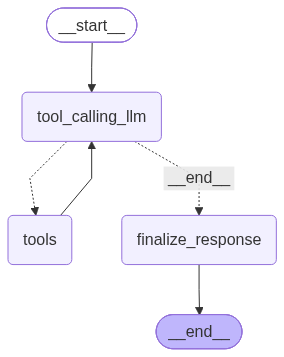

In [77]:
from IPython.display import Image, display

try:
    display(Image(financial_bot.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render the diagram (this needs internet access to mermaid.ink):", e)

## Running it

`run_financial_chatbot` now takes a `thread_id`, so calling it twice with the
same id continues the same conversation, and calling it with a new id starts
a fresh one. This is what makes the follow-up example below work.

In [78]:
from IPython.display import Markdown


def run_financial_chatbot(query: str, thread_id: str = "default", show_steps: bool = True):
    config = {"configurable": {"thread_id": thread_id}}

    print("=" * 78)
    print(f"Question: {query}")
    print("-" * 78)

    result = financial_bot.invoke({"messages": [{"role": "user", "content": query}]}, config=config)
    messages = result["messages"]

    chart_paths = []
    for m in messages:
        if show_steps and m.type == "ai" and getattr(m, "tool_calls", None):
            calls = ", ".join(f"{c['name']}({c['args']})" for c in m.tool_calls)
            print(f"[model requests tool call] {calls}")
        if show_steps and m.type == "tool":
            preview = m.content[:120].replace("\n", " ")
            print(f"[tool result: {m.name}] {preview}...")
        if m.type == "tool" and m.name == "plot_stock_chart":
            found = re.search(r"charts/[\w\.]+\.png", m.content)
            if found:
                chart_paths.append(found.group())

    print("-" * 78)
    display(Markdown(messages[-1].content))

    for path in chart_paths:
        display(Image(filename=path))

    return result

### Fundamentals

A question about valuation rather than price should route to
`get_company_fundamentals`.

In [79]:
_ = run_financial_chatbot("Is Apple stock expensive right now? What's its P/E and dividend yield?", thread_id="fund-1")

Question: Is Apple stock expensive right now? What's its P/E and dividend yield?
------------------------------------------------------------------------------
[model requests tool call] get_company_fundamentals({'ticker': 'AAPL'})
[tool result: get_company_fundamentals] AAPL fundamentals: Company: Apple Inc. Sector: Technology Market cap: $4,529.2B Trailing P/E: 35.59 Forward P/E: 32.54 E...
[model requests tool call] tavily_search_results_json({'query': 'Apple dividend yield 2024'})
[tool result: tavily_search_results_json] [{"title": "Apple (AAPL) Dividend Analysis: How It's Changed Over ...", "url": "https://www.investopedia.com/articles/ma...
[model requests tool call] get_stock_quote({'ticker': 'AAPL'})
[tool result: get_stock_quote] AAPL quote: Price: $310.34 Change: +0.65 (+0.21%) Day range: $309.97 - $313.36 52 week range: $224.69 - $344.57 Volume: ...
------------------------------------------------------------------------------


**Apple (AAPL) – Valuation Snapshot**

| Metric | Current Value | What it means |
|--------|---------------|---------------|
| **Trailing P/E** | **35.6×** | Well above the S&P 500 average (~22×) and the technology‑hardware sector average (~28×). A higher P/E suggests the market is pricing in strong future growth, making the stock relatively **expensive** on a earnings basis. |
| **Forward P/E** | **32.5×** | Slightly lower than the trailing figure, indicating analysts expect earnings to rise, but it’s still high versus peers. |
| **Dividend Yield** | **≈ 0.41 %** (annual dividend $0.99 / share ÷ current price ≈ $310) | One of the lowest yields among large‑cap tech stocks (most peers are in the 1–2 % range). Apple’s focus is on growth rather than income. |

### Quick Take
- **Is Apple expensive?**  
  - **Yes, by valuation standards.** A trailing P/E of ~35× signals that investors are paying a premium for expected growth. The forward P/E remains high, reinforcing this view.  
  - **Dividend‑focused investors** will find Apple unattractive because the yield is under 0.5 %, far below the market average.

- **What drives the premium?**  
  - Consistently strong profit margins (≈ 27 %).  
  - Robust cash generation and a track record of product innovation.  
  - Market expectations of continued earnings growth, especially from services and wearables.

- **Considerations**  
  - If you prioritize capital appreciation and can tolerate lower income, Apple’s growth narrative may justify the higher multiple.  
  - If you seek income, other tech stocks with higher yields (e.g., Cisco, Intel) or dividend‑focused sectors may be more suitable.

### Portfolio performance

A multi-ticker question with weights should route to
`get_portfolio_performance` and return one combined figure alongside the
per-holding breakdown.

In [80]:
_ = run_financial_chatbot(
    "I hold a portfolio of 50% Apple, 30% Microsoft, and 20% Nvidia. How has it performed over the last 3 months?",
    thread_id="portfolio-1",
)

Question: I hold a portfolio of 50% Apple, 30% Microsoft, and 20% Nvidia. How has it performed over the last 3 months?
------------------------------------------------------------------------------
[model requests tool call] get_portfolio_performance({'period': '3mo', 'tickers': ['AAPL', 'MSFT', 'NVDA'], 'weights': [0.5, 0.3, 0.2]})
[tool result: get_portfolio_performance] Portfolio performance over 3mo: AAPL (50%): +0.74% MSFT (30%): +17.35% NVDA (20%): -2.86%  Combined weighted return: +5....
------------------------------------------------------------------------------


### Portfolio 3‑Month Performance (as of today)

- **Apple (AAPL) – 50% weight:** **+0.74%**
- **Microsoft (MSFT) – 30% weight:** **+17.35%**
- **Nvidia (NVDA) – 20% weight:** **‑2.86%**

**Combined weighted return:** **+5.00%** over the past three months.

*The strong gain in Microsoft more than offset the modest rise in Apple and the slight dip in Nvidia, resulting in an overall 5 % upside for the portfolio.*

### Multi-turn memory

The first message names Tesla explicitly. The second message reuses the
same `thread_id` and never mentions a ticker at all, relying entirely on the
conversation history for the model to understand what "the same" refers to.

Question: Show me a 3 month price chart for Tesla
------------------------------------------------------------------------------
[model requests tool call] plot_stock_chart({'period': '3mo', 'ticker': 'TSLA'})
[tool result: plot_stock_chart] Chart saved to charts/TSLA_3mo.png. Over the last 3mo, TSLA moved from $433.59 to $348.95 (-19.52%), with a high of $442...
------------------------------------------------------------------------------


## Tesla (TSLA) – 3‑Month Price Chart

- **Start price (3 months ago):** **$433.59**  
- **Current price:** **$348.95**  
- **Change:** **‑19.5 %** over the period  
- **High:** **$442.10**  
- **Low:** **$298.32**  

**Chart:** The plotted chart (saved as `charts/TSLA_3mo.png`) shows a clear downtrend, with the stock peaking near $442 in early May before slipping steadily to the current $349 level, hitting a trough around $298 in late July.

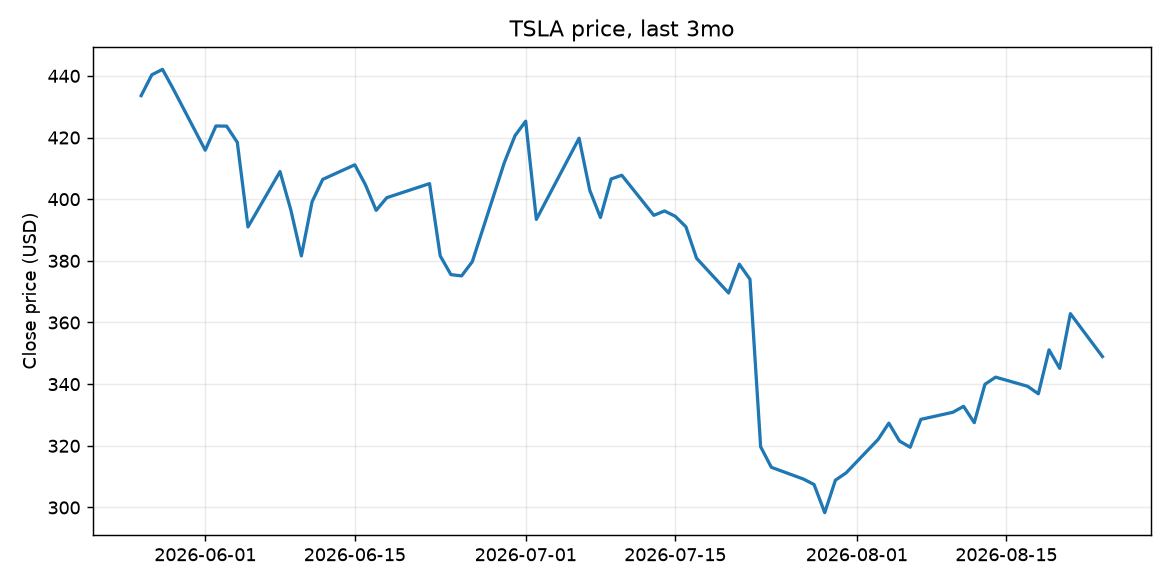

In [81]:
_ = run_financial_chatbot("Show me a 3 month price chart for Tesla", thread_id="memory-1")

Question: Now do the same for Microsoft
------------------------------------------------------------------------------
[model requests tool call] plot_stock_chart({'period': '3mo', 'ticker': 'TSLA'})
[tool result: plot_stock_chart] Chart saved to charts/TSLA_3mo.png. Over the last 3mo, TSLA moved from $433.59 to $348.95 (-19.52%), with a high of $442...
[model requests tool call] plot_stock_chart({'period': '3mo', 'ticker': 'MSFT'})
[tool result: plot_stock_chart] Chart saved to charts/MSFT_3mo.png. Over the last 3mo, MSFT moved from $415.25 to $487.31 (+17.35%), with a high of $505...
------------------------------------------------------------------------------


## Microsoft (MSFT) – 3‑Month Price Chart

- **Start price (3 months ago):** **$415.25**  
- **Current price:** **$487.31**  
- **Change:** **+17.4 %** over the period  
- **High:** **$505.11**  
- **Low:** **$352.17**  

**Chart:** The plotted chart (saved as `charts/MSFT_3mo.png`) shows a strong upward trend, with the stock climbing from the low‑$410s to a recent high above $505 before settling near $487. This reflects a solid rally over the past three months.

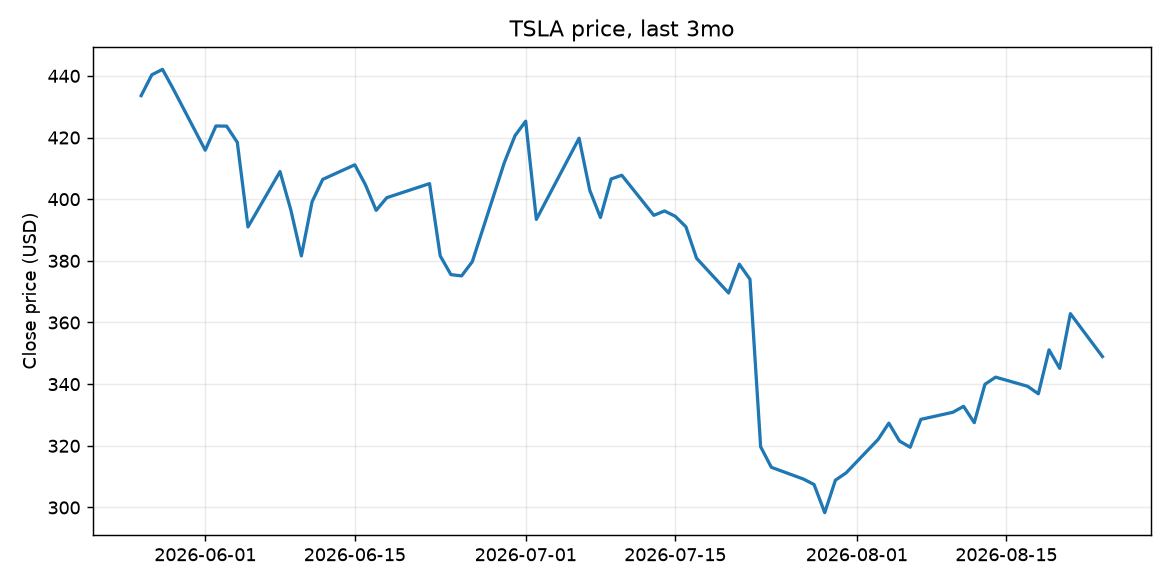

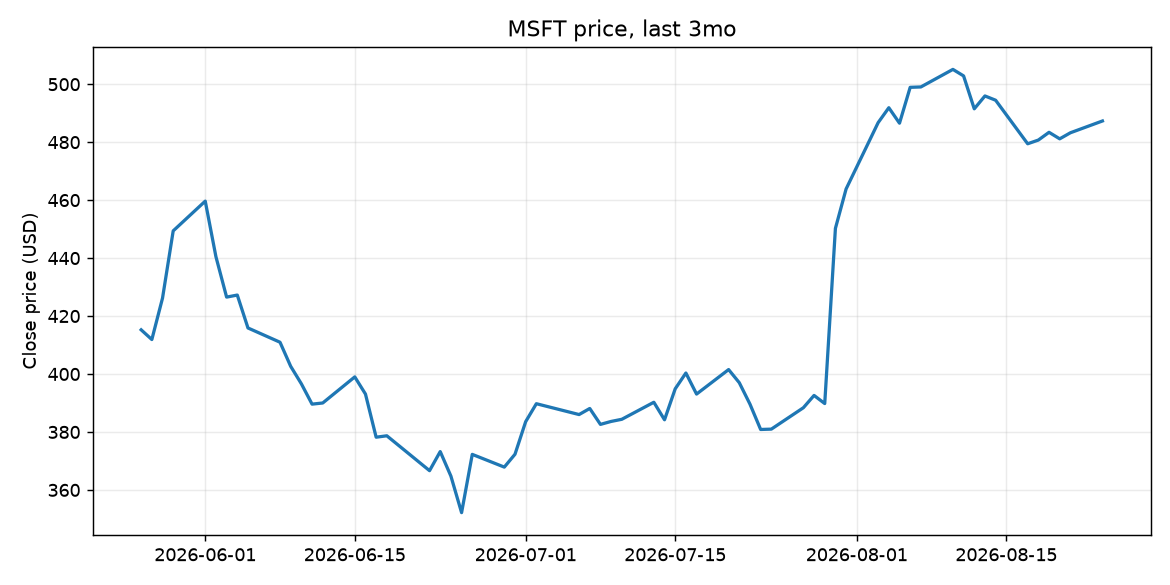

In [82]:
_ = run_financial_chatbot("Now do the same for Microsoft", thread_id="memory-1")

### Market sentiment, for a stock and for an index

Two separate calls, one naming a company and one naming a broad index, to
confirm the tool works for both.

In [83]:
_ = run_financial_chatbot("What is the current market sentiment around Tesla?", thread_id="sentiment-1")

Question: What is the current market sentiment around Tesla?
------------------------------------------------------------------------------
[model requests tool call] get_market_sentiment({'query': 'Tesla'})
[tool result: get_market_sentiment] Sentiment for Tesla: Neutral All four headlines are generic stock quote or data pages without explicit positive or negat...
------------------------------------------------------------------------------


**Current Market Sentiment for Tesla (TSLA)**  

- **Sentiment Rating:** **Neutral**  
- **Reasoning:** Recent headline scans show mostly generic price‑quote or data‑focused articles without clear positive or negative language, indicating a balanced market mood.  

*No strong bullish or bearish sentiment signals are evident at this time.*

In [84]:
_ = run_financial_chatbot("How is sentiment on the S&P 500 right now?", thread_id="sentiment-2")

Question: How is sentiment on the S&P 500 right now?
------------------------------------------------------------------------------
[model requests tool call] get_market_sentiment({'query': 'S&P 500'})
[tool result: get_market_sentiment] Sentiment for S&P 500: Mixed While one headline highlights a record close and strongest week, another notes a slip from ...
------------------------------------------------------------------------------


### Current Sentiment on the S&P 500

- **Overall sentiment:** **Mixed**  
- **Key drivers:**  
  - **Optimistic:** Record‑close rally and the strongest weekly gain since April (highlighted in recent headlines).  
  - **Cautious:** A pull‑back from the recent high, with analysts noting potential downside risk.

**Takeaway:** Investors are balancing optimism from the recent record highs with caution after the recent slip, resulting in a mixed market mood.

### Guardrail check

This question is deliberately phrased to invite a buy or sell recommendation,
to confirm the `finalize_response` node catches it and appends the
disclaimer as a separate message.

In [85]:
result = run_financial_chatbot("Should I buy Tesla stock right now?", thread_id="guardrail-1")

print("\nLast two messages in state, to show the disclaimer was appended separately:")
for m in result["messages"][-2:]:
    print(f"[{m.type}] {m.content[:200]}")

Question: Should I buy Tesla stock right now?
------------------------------------------------------------------------------
[model requests tool call] get_stock_quote({'ticker': 'TSLA'})
[tool result: get_stock_quote] TSLA quote: Price: $348.95 Change: -14.98 (-4.12%) Day range: $348.26 - $363.24 52 week range: $297.38 - $498.83 Volume:...
[model requests tool call] get_company_fundamentals({'ticker': 'TSLA'})
[tool result: get_company_fundamentals] TSLA fundamentals: Company: Tesla, Inc. Sector: Consumer Cyclical Market cap: $1,378.2B Trailing P/E: 320.14 Forward P/E...
[model requests tool call] get_market_sentiment({'query': 'Tesla stock'})
[tool result: get_market_sentiment] Sentiment for Tesla stock: Neutral The listed sources are generic stock quote or analysis tool pages without explicit po...
------------------------------------------------------------------------------


This is general market information, not personalized financial advice. Consider speaking with a licensed financial advisor before making investment decisions.


Last two messages in state, to show the disclaimer was appended separately:
[ai] **Tesla (TSLA) – Quick Decision Snapshot**

| Metric | Current Value |
|--------|---------------|
| **Price** | **$348.95** (‑4.12% today) |
| **Market Cap** | **$1.38 T** |
| **Trailing P/E** | **320
[ai] This is general market information, not personalized financial advice. Consider speaking with a licensed financial advisor before making investment decisions.
